<a href="https://colab.research.google.com/github/DaiMeotti/challenge-telecomx-2/blob/v2-relatorio/TelecomX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📶 Telecom X – Parte 2: Prevendo Churn

In [ ]:
import pandas as pd

In [ ]:
df_telecomx = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ONE Alura/Challenges/TelecomX_2/TelecomX_2.csv')

In [ ]:
df_telecomx.head()

,ID_Cliente,Cancelamento,Genero_Biolgico,Cidadao_Senior,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Online,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Custo_Diario
0,0002-ORFBO,0,Feminino,0,1,1,9,1,Nao,DSL,...,0,1,1,0,Um ano,1,Cheque por correio,65.6,593.30,2.186667
1,0003-MKNFE,0,Masculino,0,0,0,9,1,Sim,DSL,...,0,0,0,1,Mensal,0,Cheque por correio,59.9,542.40,1.996667
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,Nao,Fibra otica,...,1,0,0,0,Mensal,1,Cheque eletrônico,73.9,280.85,2.463333
3,0011-IGKFF,1,Masculino,1,1,0,13,1,Nao,Fibra otica,...,1,0,1,1,Mensal,1,Cheque eletrônico,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,Nao,Fibra otica,...,0,1,1,0,Mensal,1,Cheque por correio,83.9,267.40,2.796667


In [ ]:
df_telecomx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            7032 non-null   object 
 1   Cancelamento          7032 non-null   int64  
 2   Genero_Biolgico       7032 non-null   object 
 3   Cidadao_Senior        7032 non-null   int64  
 4   Parceiro              7032 non-null   int64  
 5   Dependentes           7032 non-null   int64  
 6   Meses_Contrato        7032 non-null   int64  
 7   Servico_Telefone      7032 non-null   int64  
 8   Multiplas_Linhas      7032 non-null   object 
 9   Servico_Internet      7032 non-null   object 
 10  Seguraca_Online       7032 non-null   int64  
 11  Backup_Online         7032 non-null   int64  
 12  Protecao_Dispositivo  7032 non-null   int64  
 13  Suporte_Tecnico       7032 non-null   int64  
 14  Streaming_TV          7032 non-null   int64  
 15  Streaming_Filmes     

In [ ]:
# Eliminando coluna ID já que identificadores únicos não ajudam na previsão da evasão.
df = df_telecomx.drop(columns=['ID_Cliente'])

In [ ]:
# Transformando variáveis categóricas em formato numérico para torná-las compatíveis com algoritmos de machine learning.

colunas_categoricas = df.select_dtypes(include='object').columns.tolist()

# One-Hot Encoding
df_transformado = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

In [ ]:
# Calculando a proporção de clientes que evadiram em relação aos que permaneceram ativos.

contagem_cancelamento = df_transformado['Cancelamento'].value_counts()

proporcao_cancelamento = (contagem_cancelamento / len(df_transformado)) * 100

proporcao_formatada = proporcao_cancelamento.round(2)

print("Contagem de clientes por classe:")
print(contagem_cancelamento)
print("\nProporção de clientes por classe:")
print(proporcao_formatada.astype(str) + '%')

Contagem de clientes por classe:
Cancelamento
0    5163
1    1869
Name: count, dtype: int64

Proporção de clientes por classe:
Cancelamento
0    73.42%
1    26.58%
Name: count, dtype: object


In [ ]:
pip install imbalanced-learn

In [ ]:
# Aplicanndo técnicas de balanceamento

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df_transformado.drop('Cancelamento', axis=1)
y = df_transformado['Cancelamento']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Verificando a nova distribuição de classes
print('Distribuição da classe de treino original:', y_train.value_counts())
print('Distribuição da classe de treino após SMOTE:', y_train_resampled.value_counts())

Distribuição da classe de treino original: Cancelamento
0    3614
1    1308
Name: count, dtype: int64
Distribuição da classe de treino após SMOTE: Cancelamento
1    3614
0    3614
Name: count, dtype: int64


In [ ]:
# Padronizando os dados

from sklearn.preprocessing import StandardScaler

colunas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

Correlação com a variável 'Cancelamento':
Cancelamento                                            1.000000
Tipo_Contrato_Mensal                                    0.404565
Servico_Internet_Fibra otica                            0.307463
Metodo_Pagamento_Cheque eletrônico                      0.301455
Custo_Diario                                            0.192858
Cobranca_Mensal                                         0.192858
Fatura_Online                                           0.191454
Cidadao_Senior                                          0.150541
Streaming_TV                                            0.063254
Streaming_Filmes                                        0.060860
Multiplas_Linhas_Sim                                    0.040033
Servico_Telefone                                        0.011691
Genero_Biolgico_Masculino                              -0.008545
Multiplas_Linhas_Sem servico de telefone               -0.011691
Protecao_Dispositivo                            

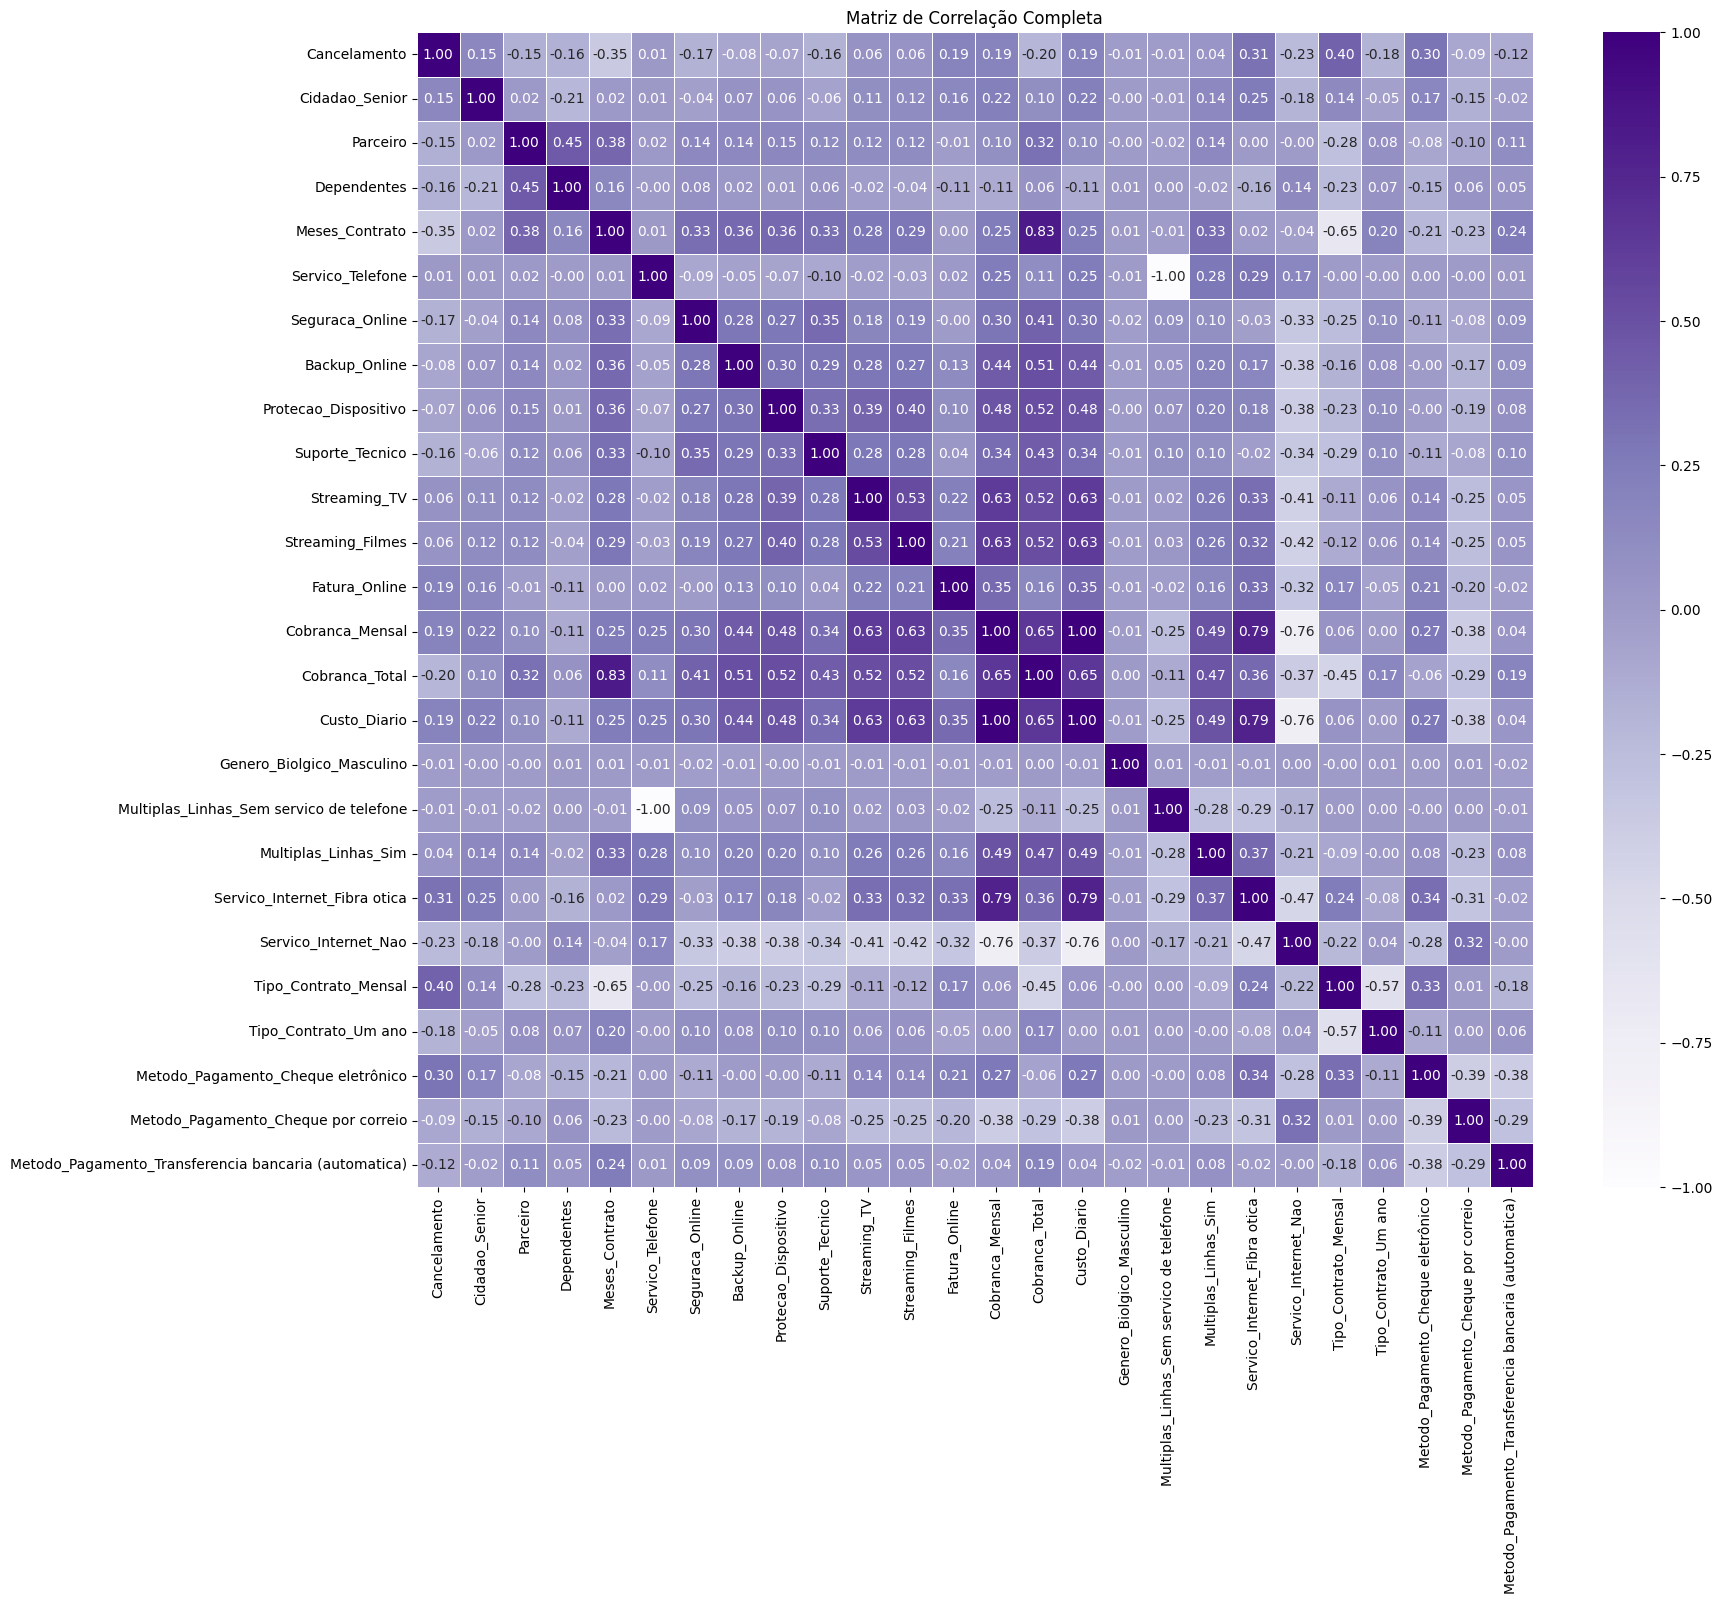

In [ ]:
# Gerando matriz de correlação para identificar relações entre variáveis numéricas.

import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df_transformado.corr()

correlacao_cancelamento = correlation_matrix['Cancelamento'].sort_values(ascending=False)
print("Correlação com a variável 'Cancelamento':")
print(f'{correlacao_cancelamento}\n\n')

plt.figure(figsize=(18, 15))

# Mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap='Purples', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação Completa')
plt.show()

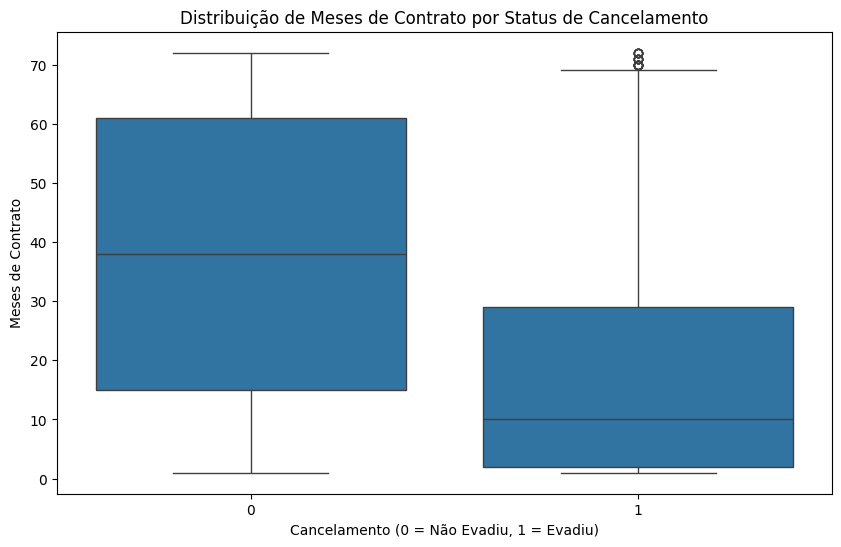

In [ ]:
# Relacionnamento de vvariáveis com a evasão

plt.figure(figsize=(10, 6))
sns.boxplot(x='Cancelamento', y='Meses_Contrato', data=df_transformado)
plt.title('Distribuição de Meses de Contrato por Status de Cancelamento')
plt.xlabel('Cancelamento (0 = Não Evadiu, 1 = Evadiu)')
plt.ylabel('Meses de Contrato')
plt.show()

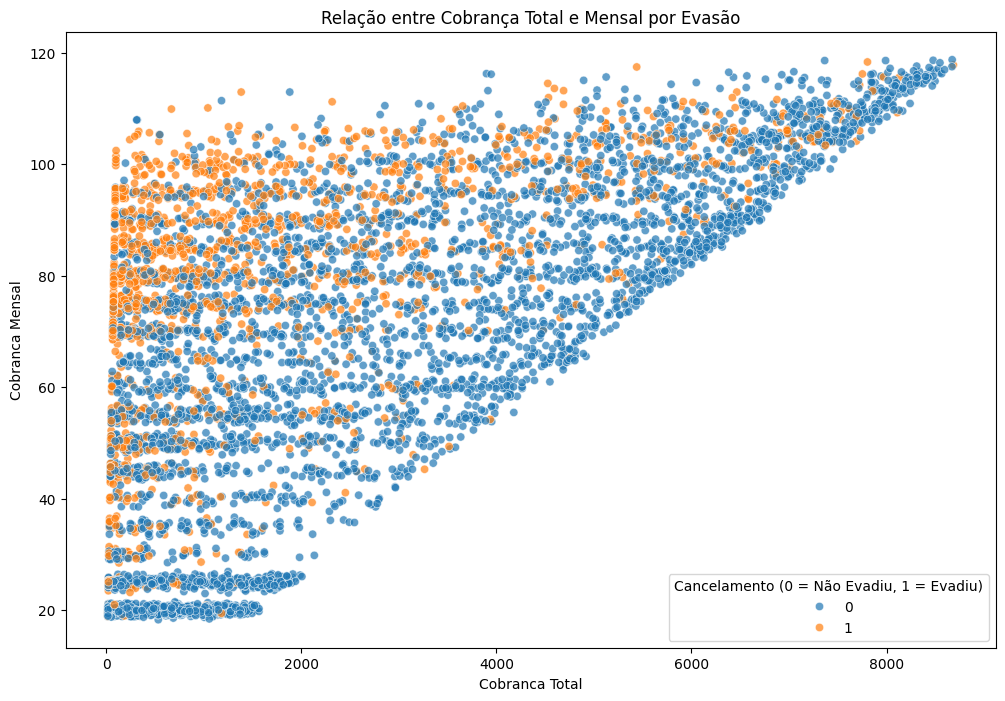

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Cobranca_Total', y='Cobranca_Mensal', hue='Cancelamento', data=df_transformado, alpha=0.7)
plt.title('Relação entre Cobrança Total e Mensal por Evasão')
plt.xlabel('Cobranca Total')
plt.ylabel('Cobranca Mensal')
plt.legend(title='Cancelamento (0 = Não Evadiu, 1 = Evadiu)')
plt.show()

In [ ]:
# Dividindo o conjunto de dados em treino e teste

from sklearn.model_selection import train_test_split

X = df_transformado.drop('Cancelamento', axis=1)
y = df_transformado['Cancelamento']

# 70% treino e 30% teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print("\nProporção da classe no conjunto de treino:")
print(y_train.value_counts(normalize=True))
print("\nProporção da classe no conjunto de teste:")
print(y_test.value_counts(normalize=True))

Tamanho do conjunto de treino (X_train): (4922, 25)
Tamanho do conjunto de teste (X_test): (2110, 25)

Proporção da classe no conjunto de treino:
Cancelamento
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Proporção da classe no conjunto de teste:
Cancelamento
0    0.734123
1    0.265877
Name: proportion, dtype: float64


In [ ]:
# Criação do primeiro modelo: Padronização dos Dados Para a Regressão Logística

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

colunas_numericas = X_train_resampled.select_dtypes(include=['float64']).columns

scaler = StandardScaler()
X_train_scaled = X_train_resampled.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_numericas] = scaler.fit_transform(X_train_scaled[colunas_numericas])
X_test_scaled[colunas_numericas] = scaler.transform(X_test_scaled[colunas_numericas])

In [ ]:
# Treinamento Regressão Logística

from sklearn.linear_model import LogisticRegression

modelo_rl = LogisticRegression(random_state=42)
modelo_rl.fit(X_train_scaled, y_train_resampled)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [ ]:
# Aumentando o número de iterações

from sklearn.linear_model import LogisticRegression

modelo_rl = LogisticRegression(random_state=42, max_iter=1000)
modelo_rl.fit(X_train_scaled, y_train_resampled)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Criação do segundo modelo: Treinamento Random Forest

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

--- Avaliação do Modelo: Regressão Logística ---
Acurácia: 0.7630
Precisão: 0.5443
Recall: 0.6684
F1-Score: 0.6000




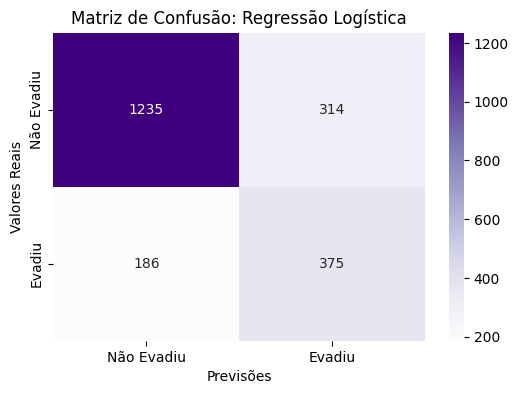




--- Avaliação do Modelo: Random Forest ---
Acurácia: 0.7735
Precisão: 0.5732
Recall: 0.5793
F1-Score: 0.5762




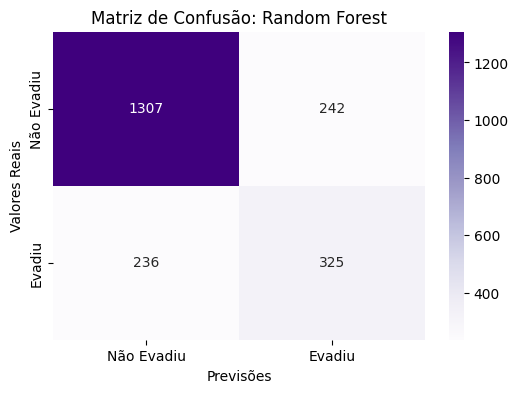

In [ ]:
# Avaliando os modelos

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def avaliar_modelo(modelo, X_test, y_test, nome_modelo):
    """Função para calcular e exibir métricas de avaliação e a matriz de confusão."""
    y_pred = modelo.predict(X_test)

    print(f"--- Avaliação do Modelo: {nome_modelo} ---")
    print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}\n\n")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Não Evadiu', 'Evadiu'],
                yticklabels=['Não Evadiu', 'Evadiu'])
    plt.title(f'Matriz de Confusão: {nome_modelo}')
    plt.ylabel('Valores Reais')
    plt.xlabel('Previsões')
    plt.show()
    print("\n" + "="*50 + "\n\n")

# Avaliando a Regressão Logística (com dados padronizados)
avaliar_modelo(modelo_rl, X_test_scaled, y_test, "Regressão Logística")

# Avaliando o Random Forest (com dados não-padronizados)
avaliar_modelo(modelo_rf, X_test, y_test, "Random Forest")

In [57]:
'''
=== Análise e Comparação dos Modelos ===
Ao analisar as métricas e as matrizes de confusão, podemos tirar as seguintes conclusões:

* Acurácia: O Random Forest teve uma acurácia ligeiramente maior (77,35%) que a da Regressão Logística (76,30%).
* Precisão: O Random Forest também superou a Regressão Logística em precisão (57,32% vs. 54,43%).
* Recall: Aqui, a Regressão Logística foi superior (66,84% vs. 57,93%).
* F1-Score: O F1-score é uma média entre precisão e recall.

Conclusão: Random Forest é o modelo com melhor desempenho geral, com maior acurácia e precisão. No entanto, a Regressão Logística teve um desempenho significativamente melhor na métrica de recall, o que é fundamental para o problema de evasão.

'''

'\n=== Análise e Comparação dos Modelos ===\nAo analisar as métricas e as matrizes de confusão, podemos tirar as seguintes conclusões:\n\n* Acurácia: O Random Forest teve uma acurácia ligeiramente maior (77,35%) que a da Regressão Logística (76,30%). \n* Precisão: O Random Forest também superou a Regressão Logística em precisão (57,32% vs. 54,43%). \n* Recall: Aqui, a Regressão Logística foi superior (66,84% vs. 57,93%).  \n* F1-Score: O F1-score é uma média entre precisão e recall. \n\n\n'

In [ ]:
# Análise das Variáveis mais relevantes com Regressão Logística

coeficientes_rl = pd.DataFrame(modelo_rl.coef_.T,
                               index=X_train_scaled.columns,
                               columns=['Coeficiente'])

# Ordenar os coeficientes por valor absoluto
coeficientes_rl['Abs_Coeficiente'] = coeficientes_rl['Coeficiente'].abs()
coeficientes_rl = coeficientes_rl.sort_values(by='Abs_Coeficiente', ascending=False)

print("Principais variáveis do modelo de Regressão Logística:")
print(coeficientes_rl[['Coeficiente']].head(10))

Principais variáveis do modelo de Regressão Logística:
                                          Coeficiente
Multiplas_Linhas_Sem servico de telefone     2.266721
Servico_Internet_Nao                         1.984289
Tipo_Contrato_Mensal                         1.975190
Servico_Internet_Fibra otica                -1.776663
Cobranca_Mensal                              1.585549
Custo_Diario                                 1.585549
Metodo_Pagamento_Cheque eletrônico           1.379404
Cobranca_Total                               1.292132
Tipo_Contrato_Um ano                         1.282563
Suporte_Tecnico                             -1.230698


In [ ]:
# Análise das Variáveis mais relevantes com Random Forest

importancia_rf = pd.DataFrame({'Variavel': X_train_resampled.columns,
                               'Importancia': modelo_rf.feature_importances_})

# Ordenar as variáveis pela importância
importancia_rf = importancia_rf.sort_values(by='Importancia', ascending=False)

print("Principais variáveis do modelo Random Forest:")
print(importancia_rf.head(10))

Principais variáveis do modelo Random Forest:
                              Variavel  Importancia
3                       Meses_Contrato     0.119607
13                      Cobranca_Total     0.118560
20                Tipo_Contrato_Mensal     0.113811
14                        Custo_Diario     0.106562
12                     Cobranca_Mensal     0.100110
22  Metodo_Pagamento_Cheque eletrônico     0.085339
18        Servico_Internet_Fibra otica     0.052823
5                      Seguraca_Online     0.034995
8                      Suporte_Tecnico     0.033808
1                             Parceiro     0.026803


# RELATÓRIO FINAL

### 🎯 **Objetivo**

O objetivo deste projeto foi desenvolver modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços, já que a empresa **Telecom X** quer antecipar o problema da evasão.



## Conclusão

Com base na análise realizada, aqui está um resumo de todas as nossas descobertas:

O modelo de **Random Forest** apresentou o melhor desempenho geral em termos de acurácia, enquanto a **Regressão Logística** se destacou na capacidade de identificar a maioria dos clientes em risco de evasão (Recall). No entanto, a análise de ambos os modelos apontou para os mesmos fatores-chave que influenciam o cancelamento de serviços.

---

**Principais Fatores que Aumentam a Evasão**

* **Tipo de Contrato:** Clientes com **contratos mensais** são o grupo de maior risco. A ausência de um compromisso de longo prazo facilita a decisão de cancelar.

* **Cobrança:** Clientes com **cobranças mensais e totais mais altas** têm maior probabilidade de evadir. Isso pode estar relacionado à percepção de valor pelo dinheiro ou insatisfação com o preço.

* **Serviço de Internet:** Clientes que utilizam o **serviço de internet de fibra óptica** da empresa têm uma correlação positiva com a evasão. Isso sugere possíveis problemas de qualidade ou instabilidade no serviço que levam à insatisfação.

* **Pagamento:** O método de pagamento por **cheque eletrônico** também está associado a um risco maior de cancelamento.



---



**Principais Fatores que Diminuem a Evasão**

* **Meses de Contrato:** O **tempo de contrato** é o fator mais importante para a lealdade. Clientes de longa data são significativamente menos propensos a cancelar.

* **Serviços Adicionais:** A oferta de serviços como **Suporte Técnico Online** atua como um fator de retenção, diminuindo o risco de evasão.

* **Parceiros e Dependentes:** Clientes com **parceiros e dependentes** tendem a permanecer com a empresa, indicando que a decisão de cancelar pode envolver mais pessoas.




## Estratégias de Retenção Propostas

Em relação aos insights acima, propomos as seguintes estratégias:

* **Oferecer Incentivos para Contratos de Longo Prazo:** Criar promoções ou descontos para clientes que migrarem de contratos mensais para anuais.

* **Monitorar Clientes de Alto Risco:** Implementar um sistema de alerta para clientes com **contratos mensais e cobranças altas**. Equipes de retenção podem entrar em contato proativamente com esses clientes para entender suas necessidades.

* **Melhorar a Qualidade da Fibra Óptica:** Realizar uma análise mais profunda sobre os problemas que os clientes de fibra óptica podem estar enfrentando, seja na qualidade do serviço ou no suporte.

* **Otimizar o Suporte Técnico:** Reforçar a importância do suporte técnico para a retenção de clientes. Avaliar a possibilidade de promover esse serviço ou torná-lo mais acessível.

* **Analisar Métodos de Pagamento:** Entender por que clientes que pagam com cheque eletrônico estão mais propensos a cancelar e considerar incentivar outros métodos de pagamento que gerem maior lealdade.